### Brownian motion

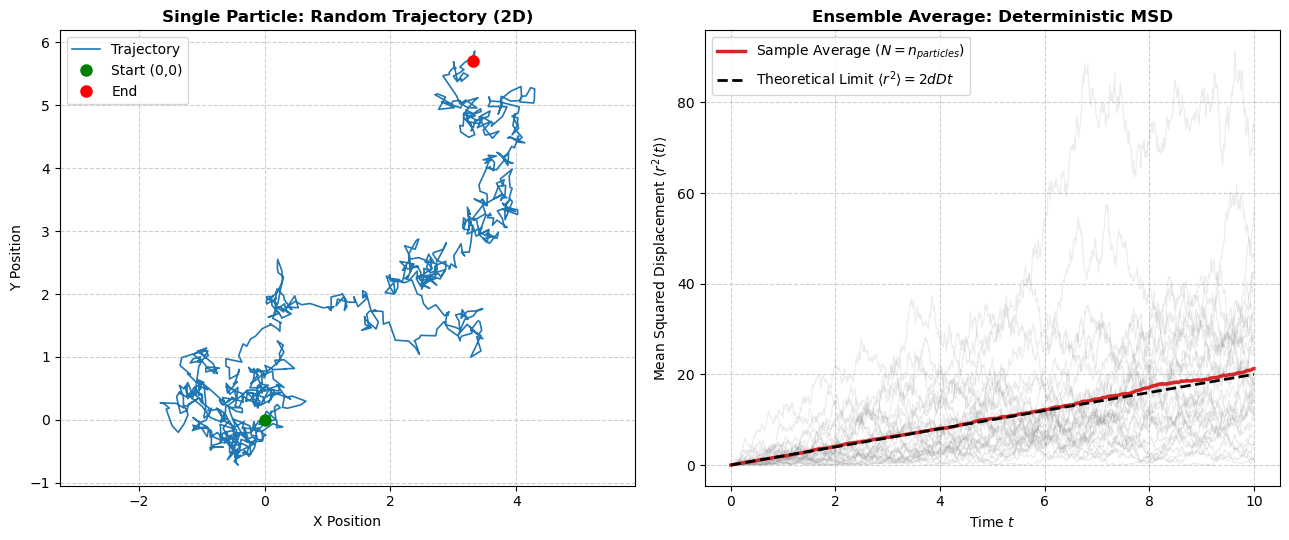

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# --- Simulation Parameters ---
n_steps = 1000      # Number of time steps
dt = 0.01           # Time step size
D = 0.5             # Diffusion coefficient
d = 2               # Spatial dimensions (2D)

# Standard deviation of spatial steps in each dimension: sqrt(2 * D * dt)
step_std = np.sqrt(2 * D * dt)

# ==========================================
# 1. Individual Brownian Motion (Random)
# ==========================================
# Generate random increments from a Normal distribution
dx = np.random.normal(loc=0.0, scale=step_std, size=(n_steps, 2))

# Cumulatively sum increments to construct trajectory starting at (0,0)
position_single = np.vstack([[0, 0], np.cumsum(dx, axis=0)])

# ==========================================
# 2. Averaged Motion of Multiple Particles (Deterministic)
# ==========================================
n_particles = 500

# Generate 3D tensor of steps: (n_particles, n_steps, 2)
all_dx = np.random.normal(loc=0.0, scale=step_std, size=(n_particles, n_steps, 2))

# Calculate trajectory for every particle starting at origin
# Shape: (n_particles, n_steps + 1, 2)
all_positions = np.zeros((n_particles, n_steps + 1, 2))
all_positions[:, 1:, :] = np.cumsum(all_dx, axis=1)

# Squared distance from origin for each particle at each time step: r^2 = x^2 + y^2
squared_displacements = np.sum(all_positions**2, axis=2)

# Average squared displacement across all particles (Ensemble Average)
mean_squared_displacement = np.mean(squared_displacements, axis=0)

# Theoretical deterministic expectation: MSD = 2 * d * D * t = 4 * D * t (in 2D)
time_vec = np.linspace(0, n_steps * dt, n_steps + 1)
theoretical_msd = 2 * d * D * time_vec

# ==========================================
# Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Plot 1: Single Stochastic Trajectory
ax1.plot(position_single[:, 0], position_single[:, 1], color='#1f77b4', lw=1.2, label='Trajectory')
ax1.plot(0, 0, 'go', markersize=8, label='Start (0,0)')
ax1.plot(position_single[-1, 0], position_single[-1, 1], 'ro', markersize=8, label='End')
ax1.set_title("Single Particle: Random Trajectory (2D)", fontsize=12, fontweight='bold')
ax1.set_xlabel("X Position")
ax1.set_ylabel("Y Position")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()
ax1.axis('equal')

# Plot 2: Mean Squared Displacement (Stochastic Average -> Deterministic Law)
# Plot a few individual squared displacements in faint gray to show variance
for i in range(min(30, n_particles)):
    ax2.plot(time_vec, squared_displacements[i], color='gray', alpha=0.15, lw=0.8)

ax2.plot(time_vec, mean_squared_displacement, color='#d62728', lw=2.5, 
         label=r'Sample Average ($N=n_{particles}$)')
ax2.plot(time_vec, theoretical_msd, 'k--', lw=2, 
         label=r'Theoretical Limit $\langle r^2 \rangle = 2dDt$')

ax2.set_title("Ensemble Average: Deterministic MSD", fontsize=12, fontweight='bold')
ax2.set_xlabel(r"Time $t$")
ax2.set_ylabel(r"Mean Squared Displacement $\langle r^2(t) \rangle$")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()